# DAY 3 TASK

### IMPORT LIBRARIES

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

### LOAD DATASET

In [6]:
fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/processed/aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/category_inflows_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

portfolio = pd.read_csv("../data/processed/portfolio_holdings_clean.csv")

folio = pd.read_csv("../data/processed/industry_folio_count_clean.csv")

## INSTALL kaleido

In [7]:
pip install --upgrade kaleido


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 17 DATA VISUALIZATIONS

### 1.NAV Trend Analysis

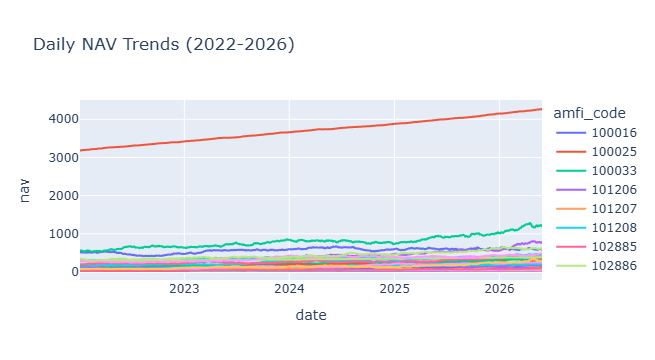

In [8]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends (2022-2026)"
)

fig.show()
fig.write_image("../reports/charts/nav_trend.png")

### Insight 
Most mutual fund schemes exhibited a steady upward NAV trend during 2023, indicating a broad-based market rally and strong investor confidence.

### 2.AUM Growth Chart

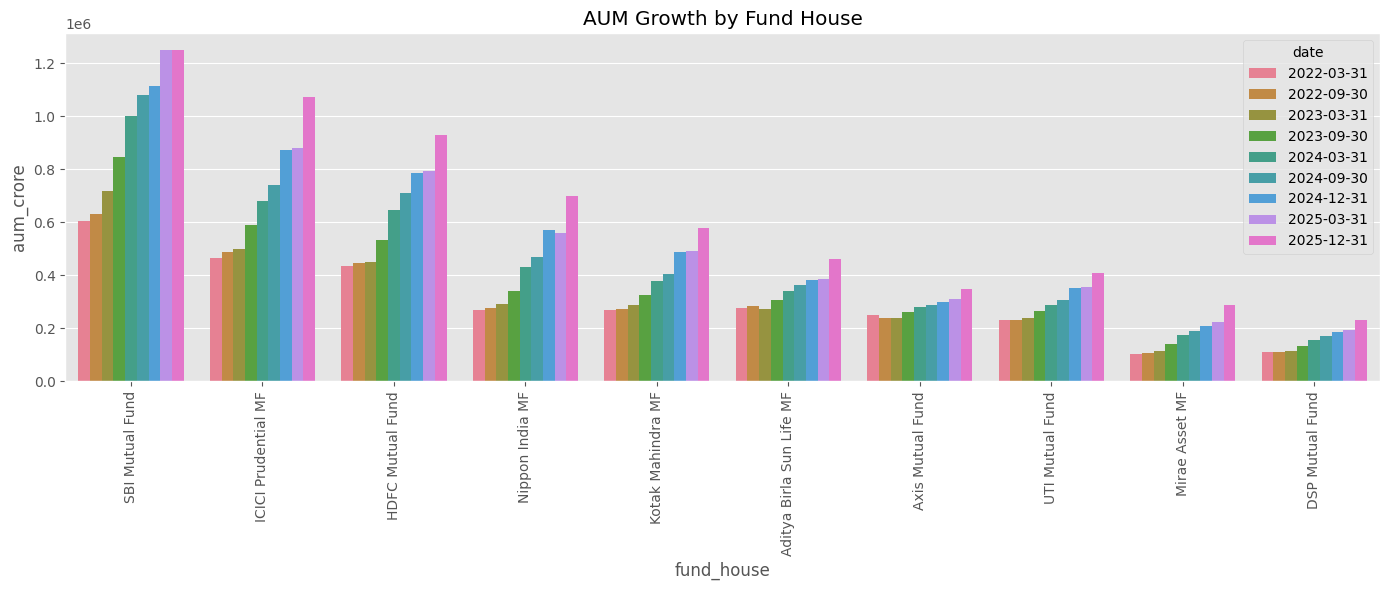

In [9]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore",
    hue="date"
)

plt.xticks(rotation=90)

plt.title("AUM Growth by Fund House")
plt.tight_layout()
plt.savefig("../reports/charts/aum_growth.png")
plt.show()

### Insight 
SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), demonstrating its dominant position in the mutual fund industry.

### 3.SIP Inflow Trend

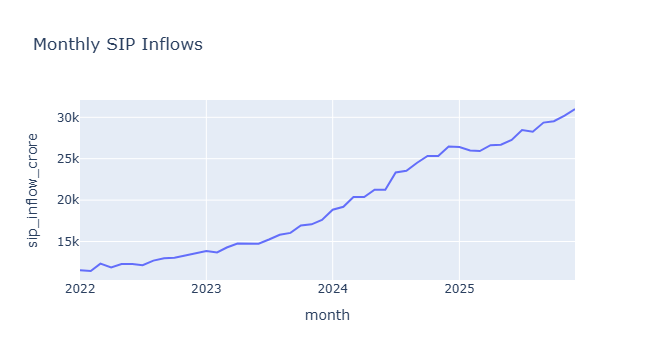

In [10]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

fig.show()
fig.write_image("../reports/charts/sip_inflow_trend.png")

### Insight 
Monthly SIP inflows increased steadily from 2022 to 2025, reflecting growing retail investor participation and disciplined investing behavior.

### 4.Category Inflow Heatmap

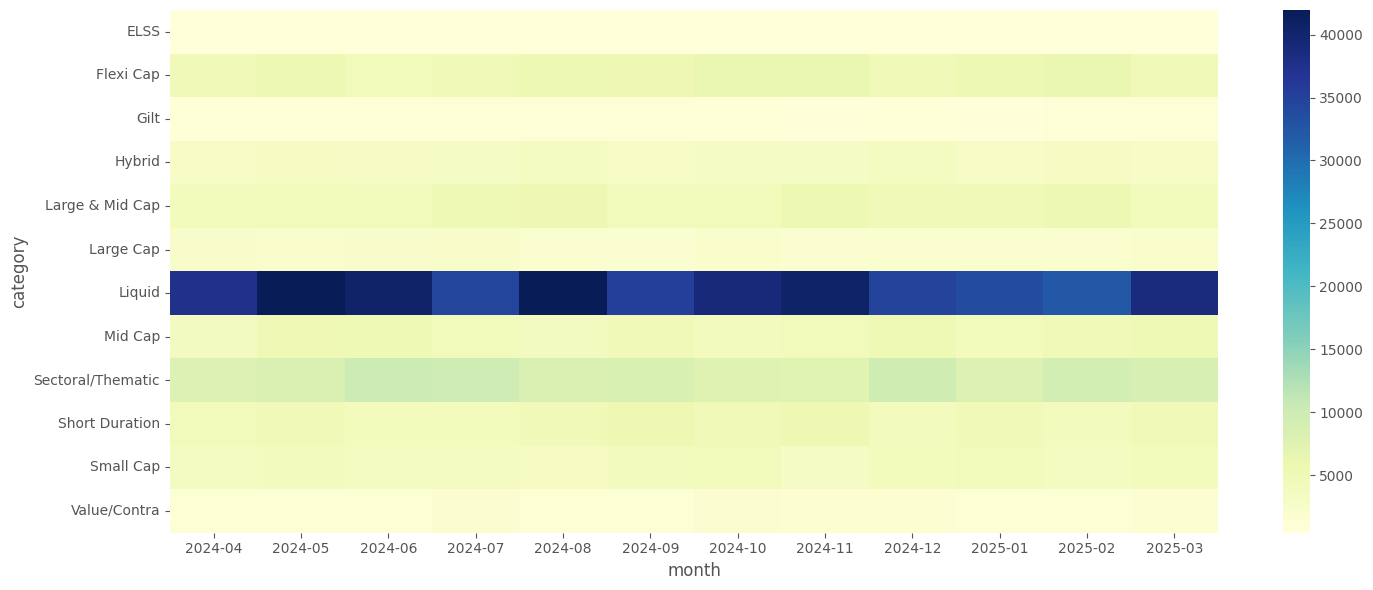

In [11]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.tight_layout()
plt.savefig("../reports/charts/category_inflow_heatmap.png")
plt.show()

### Insight 
Equity-oriented fund categories attracted the highest net inflows across most months, indicating a strong preference for growth-oriented investments.

### 5.Age Group Pie Chart

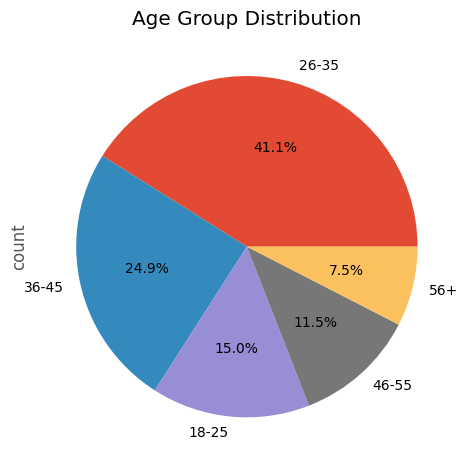

In [12]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")
plt.tight_layout()
plt.savefig("../reports/charts/age_group_distribution.png")
plt.show()

### Insight 
Investors in the working-age population contributed the largest share of mutual fund investments, highlighting their higher investment activity.

### 6.SIP Amount Boxplot

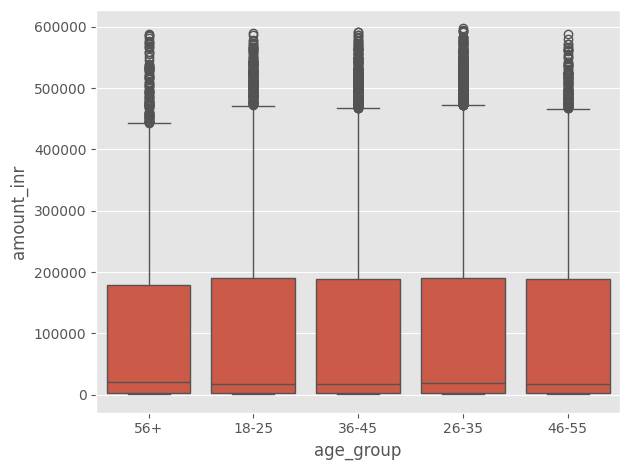

In [13]:
sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)
plt.tight_layout()
plt.savefig("../reports/charts/sip_amount_boxplot.png")
plt.show()

### Insight 
Higher variability in SIP amounts among certain age groups suggests differences in income levels, investment goals, and risk appetite.

### 7.Gender Split

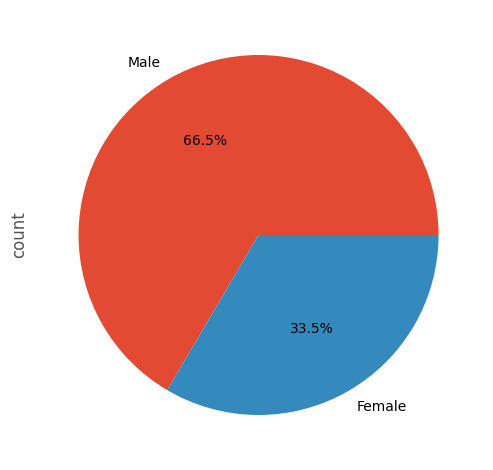

In [14]:
transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.tight_layout()
plt.savefig("../reports/charts/gender_split.png")
plt.show()

### Insight 
The gender distribution reveals the participation pattern of investors and helps identify opportunities for broader financial inclusion.

### 8.State-wise SIP Amount

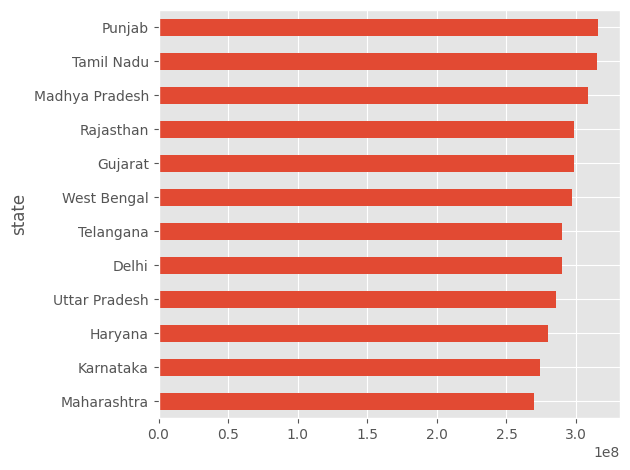

In [15]:
state_sip = transactions.groupby(
    "state"
)["amount_inr"].sum()

state_sip.sort_values().tail(15).plot(
    kind="barh"
)

plt.tight_layout()
plt.savefig("../reports/charts/state_sip_amount.png")
plt.show()

### Insight 
A few states contribute a significant portion of total SIP investments, indicating regional concentration in mutual fund adoption.

### 9.T30 vs B30 Pie Chart

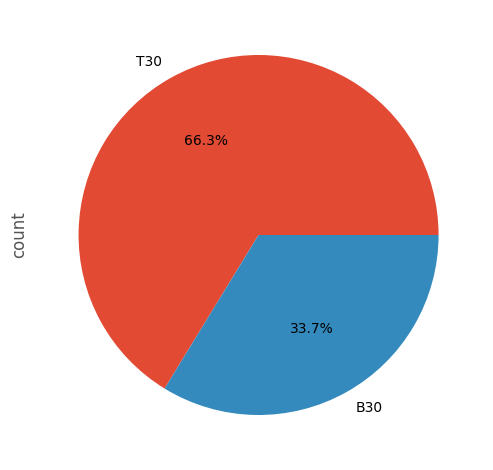

In [16]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.tight_layout()
plt.savefig("../reports/charts/city_tier_distribution.png")
plt.show()

### Insight 
T30 cities account for a larger share of investments, although B30 cities are steadily increasing their participation in mutual fund markets.

### 10.Folio Growth

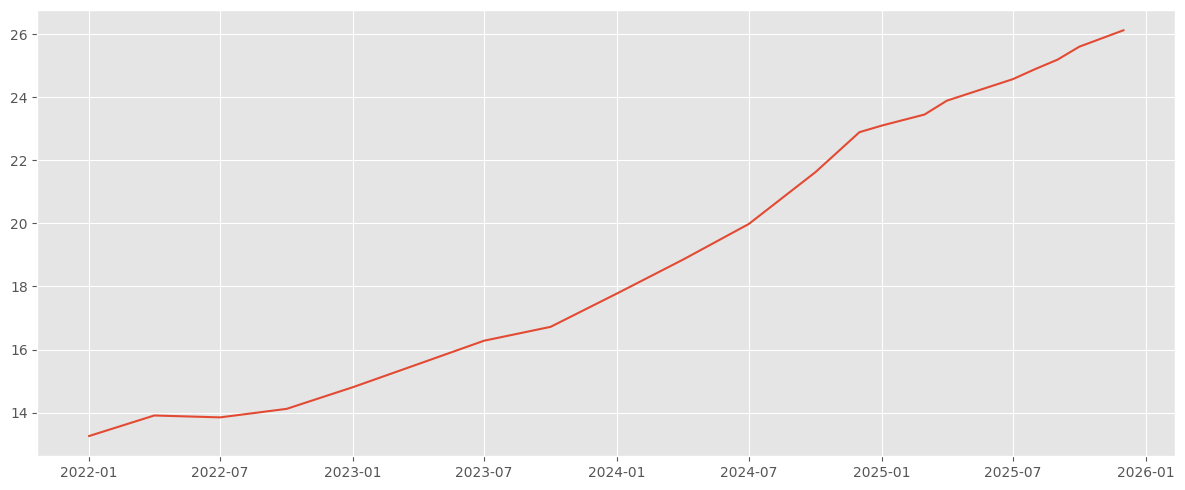

In [17]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.tight_layout()
plt.savefig("../reports/charts/folio_growth.png")
plt.show()

### Insight
The number of investor folios grew substantially between 2022 and 2025, reflecting increasing awareness and acceptance of mutual funds as an investment vehicle.

### 11.Correlation Matrix

In [18]:
top10 = nav["amfi_code"].unique()[:10]
top10

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [19]:
returns = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = returns.pct_change()
returns

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-25,-0.004227,0.000141,-0.017480,-0.015349,0.027459,0.000363,0.001133,0.016734,0.010121,0.008220,...,-0.010336,-0.000246,0.007503,-0.007358,-0.013787,-0.005188,-0.017542,0.004285,-0.020468,0.012106
2026-05-26,-0.005819,-0.000913,0.019258,-0.006544,-0.016437,0.000141,0.006033,-0.020602,0.032386,0.007191,...,-0.003700,0.000718,-0.005021,0.011365,0.002199,0.006710,0.020710,0.000369,-0.017214,-0.004138
2026-05-27,-0.009367,-0.001386,0.017756,0.004290,0.005976,0.000656,0.002134,0.002216,0.005423,0.005008,...,-0.006695,0.000609,-0.005700,0.017565,0.005080,0.006606,0.012696,-0.010131,-0.004753,-0.008480


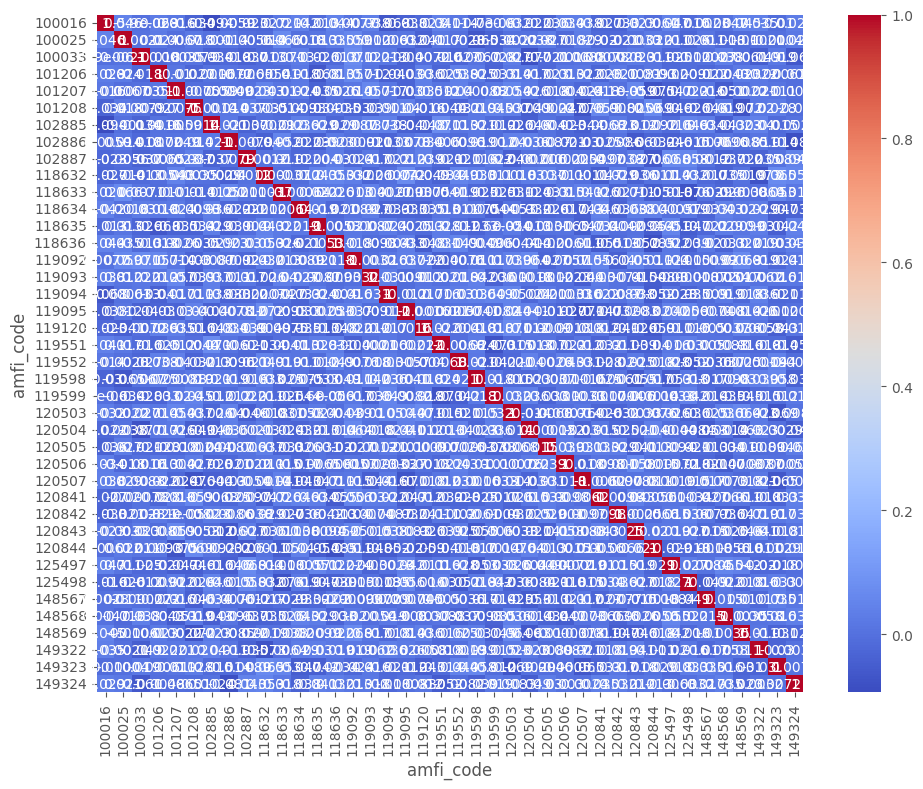

In [20]:
corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.tight_layout()
plt.savefig("../reports/charts/nav_correlation_matrix.png")
plt.show()

### 12.Sector Allocation Donut Chart

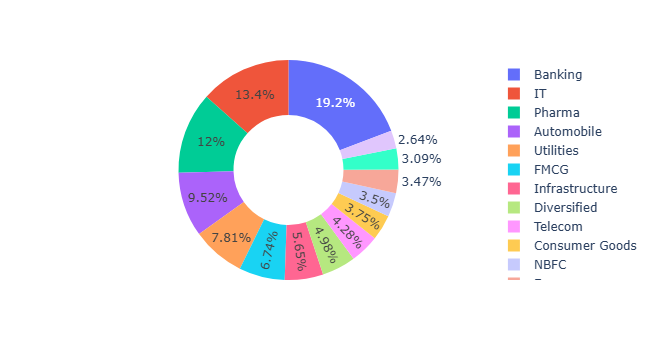

In [21]:
sector = portfolio.groupby(
    "sector"
)["weight_pct"].sum()

fig = px.pie(
    values=sector.values,
    names=sector.index,
    hole=0.5
)

fig.show()
fig.write_image("../reports/charts/sector_allocation.png")

### 13.Top 10 Funds by 5-Year Return

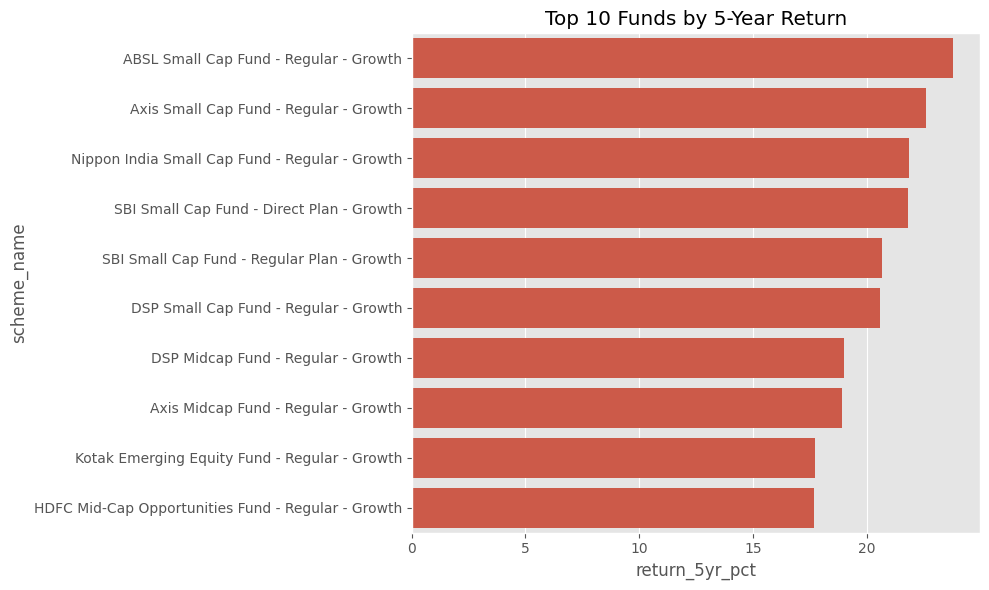

In [22]:
top_returns = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_returns,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")

plt.tight_layout()

plt.savefig("../reports/charts/top_10_returns.png")

plt.show()

### 14.Expense Ratio Distribution

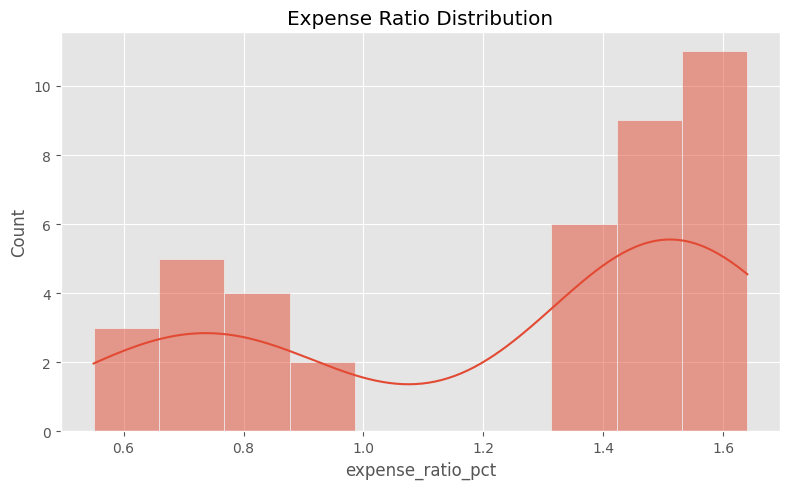

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.tight_layout()

plt.savefig("../reports/charts/expense_ratio_distribution.png")

plt.show()

### 15.Risk Grade Distribution

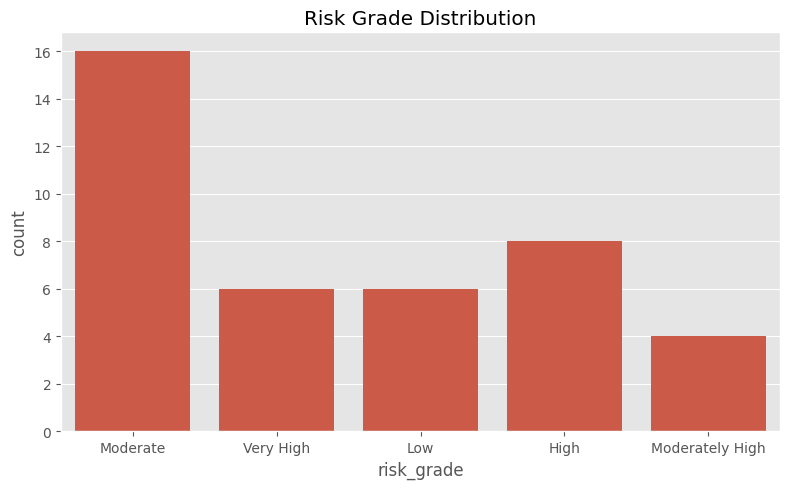

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")

plt.tight_layout()

plt.savefig("../reports/charts/risk_grade_distribution.png")

plt.show()

### 16.Top 10 Funds by Sharpe Ratio

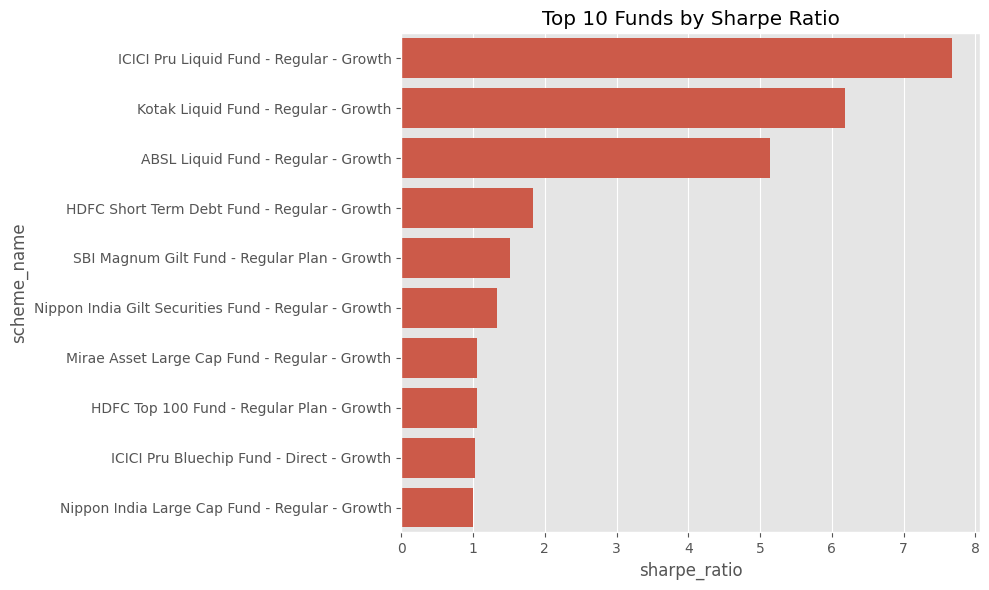

In [25]:
top_sharpe = performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig("../reports/charts/top_sharpe_ratio.png")

plt.show()

### 17.Category-wise Average Return

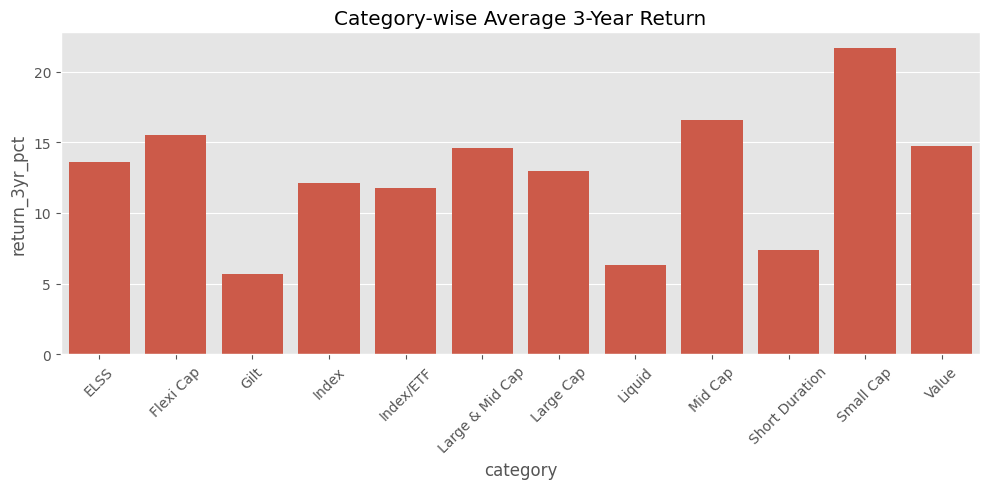

In [26]:
cat_return = performance.groupby(
    "category"
)["return_3yr_pct"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=cat_return,
    x="category",
    y="return_3yr_pct"
)

plt.xticks(rotation=45)

plt.title("Category-wise Average 3-Year Return")

plt.tight_layout()

plt.savefig("../reports/charts/category_avg_return.png")

plt.show()